# Анализ заведений общественного питания Москвы

- Автор: Малявина Дарья
- Дата: 10.02.26

### Цели и задачи проекта

Цель: Проанализировать информацию о заведениях общественного питания Москвы и сформулировать выводы

Задачи:

1. Изучить категории заведений
2. Изучить распределение заведений относительно административных районов Москвы
3. Изучить соотношение сетевых и несетевых заведений
4. Изучить количество посадочных мест в заведениях
5. Изучить рейтинг заведений
6. Выявить топ-15 популярных заведений в Москве
7. Изучить вариацию среднего чека заведения в зависимости от района

### Описание данных

**Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:**

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):

    0 — заведение не является сетевым;
    
    1 — заведение является сетевым.
    
    
- `seats` — количество посадочных мест.


**Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:**

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:

    «Средний счёт: 1000–1500 ₽»;
    
    «Цена чашки капучино: 130–220 ₽»;
    
    «Цена бокала пива: 400–600 ₽».
    
    и так далее;
    
    
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:

    Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    
    Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    
    Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
    
    
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:

    Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    
    Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    
    Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.
    
    
    

### Содержимое проекта

1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
4. Итоговый вывод и рекомендации


## 1. Загрузка данных и знакомство с ними


In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
!pip install phik

   ---------------------------------------- 0.0/678.1 kB ? eta -:--:--
   ------------------------------ --------- 524.3/678.1 kB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 678.1/678.1 kB 4.0 MB/s  0:00:00



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
rest_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Выведем общую информацию о датасете `rest_df`



In [3]:
rest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Выведем первые 5 строк датасета `rest_df`

In [4]:
rest_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


Выведем общую информацию о датасете `rest_price_df`


In [5]:
rest_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Выведем первые 5 строк датасета `rest_price_df`


In [6]:
rest_price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


---

### Промежуточный вывод


- В датасете `rest_df` 8406 строк и 9 столбцов. В двух столбцах присутствуют пропуски - `hours` и `seats`. Типы данных в датасете верные, только в столбце seats можно поменять тип данных на int.


- В датасете `rest_price_df` 4058 строк и 5 столбцов. В 4 столбцах есть пропуски - `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`. Типы данных - верные.

### Подготовка единого датафрейма

Объединим датасет `rest_df` и `rest_price_df` в датасет `df`

In [7]:
df = rest_df.merge(rest_price_df, how='left', on='id')

Проверим общую информацию о новом датасете


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


Посмторим первые 5 строк нового датасета

In [9]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


## 2. Предобработка данных

В столбце `seats` поменять тип данных на `int` пока нельзя из-за пропусков


Пока что можно оптимизировать размерность в столбце `chain` и `rating`

In [10]:
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [11]:
df['rating'] = pd.to_numeric(df['rating'], downcast='float')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float32(1), float64(3), int8(1), object(8)
memory usage: 763.6+ KB


Проверим по всем столбцам долю пропусков от всего количества строк

In [13]:
df.isna().sum()/df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

В столбцах `middle_avg_bill`, `middle_coffee_cup` пропуски естественны, так как структура данных предполагает там наличие пропусков. Пропуски в этих столбцах можно проигнорировать, как и в столбце `hours`, так как там процент пропусков около 6% (вероятнее всего эти данные были просто не добавлены, так как была добавлена из Яндекс Бизнеса). В столбцах `price` и `avg_bill` высокий процент пропусков, вероятнее всего как и hours они просто не были добавлены. Данные столбцы необходимы для дальнейшего анализа, но заменить их нельзя. Цену и средний чек нельзя заменить средним. Ниже я просто проверю есть для каждого района данные по цене и счету для дальнейшего анализа.


In [14]:
df_dis_price = df.groupby('district')['price'].count()
df_dis_price

district
Восточный административный округ            244
Западный административный округ             307
Северный административный округ             343
Северо-Восточный административный округ     309
Северо-Западный административный округ      146
Центральный административный округ         1211
Юго-Восточный административный округ        199
Юго-Западный административный округ         245
Южный административный округ                311
Name: price, dtype: int64

In [15]:
df_dis_bill = df.groupby('district')['avg_bill'].count()
df_dis_bill

district
Восточный административный округ            310
Западный административный округ             362
Северный административный округ             413
Северо-Восточный административный округ     368
Северо-Западный административный округ      185
Центральный административный округ         1292
Юго-Восточный административный округ        236
Юго-Западный административный округ         276
Южный административный округ                374
Name: avg_bill, dtype: int64

Данные есть, можно продолжить анализ.


Нормализуем данные и проверим количество уникальных значений в столбцах с названием заведений и адресами.


In [16]:
df_name = df['name'].str.strip().str.lower().nunique()
df_name

5512

In [17]:
df_address = df['address'].str.strip().str.lower().nunique()
df_address

5752

Так как некоторые заведения записываются по разным адресам, а некоторые адреса принадлежат нескольким заведениям, уникальные значения по этим столбцам не будет совпадать с количеством строк.


Проверим наличие дубликатов в связке name и address.

In [18]:
df['name'] = df['name'].astype(str).str.strip().str.lower()
df['address'] = df['address'].astype(str).str.strip().str.lower()

df.duplicated(['name', 'address'], keep=False).sum()

np.int64(8)

In [19]:
duplicates = df[df.duplicated(['name', 'address'], keep=False)] 
duplicates

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276.0,NaN,NaN,NaN,NaN


Дубликатов есть, и они связаны, вероятнее всего, с изменениями часов работы заведений.

Удалим дубликаты.

In [20]:
df = df.drop_duplicates(subset=['name', 'address'])

In [21]:
df.duplicated(['name', 'address'], keep=False).sum()

np.int64(0)

Дубликатов нет


Проверим по всему датасету явные дубликаты

In [22]:
df_dup = df[df.duplicated()]
df_dup

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup


In [23]:
df_category = df['category'].unique()
df_category

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

Явных дубликатов нет


Создаем новый столбец

In [24]:
df['is_24_7'] = df['hours'] == 'ежедневно, круглосуточно'

Проверяем результат.


In [25]:
df[(df['is_24_7'] == True)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
10,ac32978af97641bfacf996e7f5a50ee5,great room bar,"бар,паб","москва, левобережная улица, 12",Северный административный округ,"ежедневно, круглосуточно",4.5,0,102.0,средние,Цена бокала пива:250–350 ₽,NaN,NaN,True
17,b55465d0869648a295ad1d85ed9b5c4f,чайхана беш-бармак,ресторан,"москва, ленинградское шоссе, 71б, стр. 2",Северный административный округ,"ежедневно, круглосуточно",4.4,0,96.0,средние,Средний счёт:350–500 ₽,425.0,NaN,True
19,feec6bedccae44cb877d99c13f9aa5d7,пекарня,булочная,"москва, ижорский проезд, 5",Северный административный округ,"ежедневно, круглосуточно",4.4,1,NaN,NaN,NaN,NaN,NaN,True
24,0f5d22f5377340d0a81a9328e6ebdcac,drive café,кафе,"москва, улица дыбенко, 9ас1",Северный административный округ,"ежедневно, круглосуточно",4.0,1,NaN,NaN,NaN,NaN,NaN,True
49,a8bbd74669074068ab44bc567022ee27,2u-ту-ю,пиццерия,"москва, ижорская улица, 8а",Северный административный округ,"ежедневно, круглосуточно",2.7,0,NaN,NaN,Средний счёт:900 ₽,900.0,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8394,03c53ed5236948179947b46b7338d18d,намангале,кафе,"москва, ферганская улица, вл17-21",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.3,0,NaN,NaN,NaN,NaN,NaN,True
8399,71cc394927204d45b81c3a91edb47955,"пекарня, кафе-гриль",булочная,"москва, болотниковская улица, 52, корп. 2",Юго-Западный административный округ,"ежедневно, круглосуточно",4.2,0,50.0,NaN,Средний счёт:50–250 ₽,150.0,NaN,True
8403,62e8c64d4c89467aba608e39ef87616b,самовар,кафе,"москва, люблинская улица, 112а, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",3.9,0,150.0,NaN,Средний счёт:от 150 ₽,150.0,NaN,True
8404,06a0db5ecd4842d48cd6350aa923e297,чайхана sabr,кафе,"москва, люблинская улица, 112а, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,150.0,NaN,NaN,NaN,NaN,True


---

### Промежуточный вывод

В ходе предобработки данных были получены следующие результаты:

- В 6 столбцах были найдены пропуски: `hours`, `seats`, `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`. Пропуски в столбцах были оставлены без изменений.
- Типы данных в столбцах верны. В столбцах `rating`, `chain` была оптимизирована размерность.
- Дубликатов в данных не было найдено.
- Был создан столбец `is_24_7`, который отражает, работает ли заведение ежедневно и круглосуточно или нет.



## 3. Исследовательский анализ данных

---

### Задача 1

Сгруппируем количество заведений по каждой категории в абсолютных и относительных значениях и отсортируем по убыванию.


In [26]:
df_cat = df.groupby('category')['id'].count().sort_values(ascending=False)
df_cat

category
кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: id, dtype: int64

In [27]:
df_cat_per = df['category'].value_counts(normalize=True)
df_cat_per

category
кафе               0.282790
ресторан           0.243037
кофейня            0.168174
бар,паб            0.090931
пиццерия           0.075339
быстрое питание    0.071769
столовая           0.037491
булочная           0.030469
Name: proportion, dtype: float64

Всего 8 категорий заведений. Больше всего заведений представлено в категории `кафе`, `ресторан` и `кофейня
`. Ниже представим результат в виде столбчатой диаграммы.

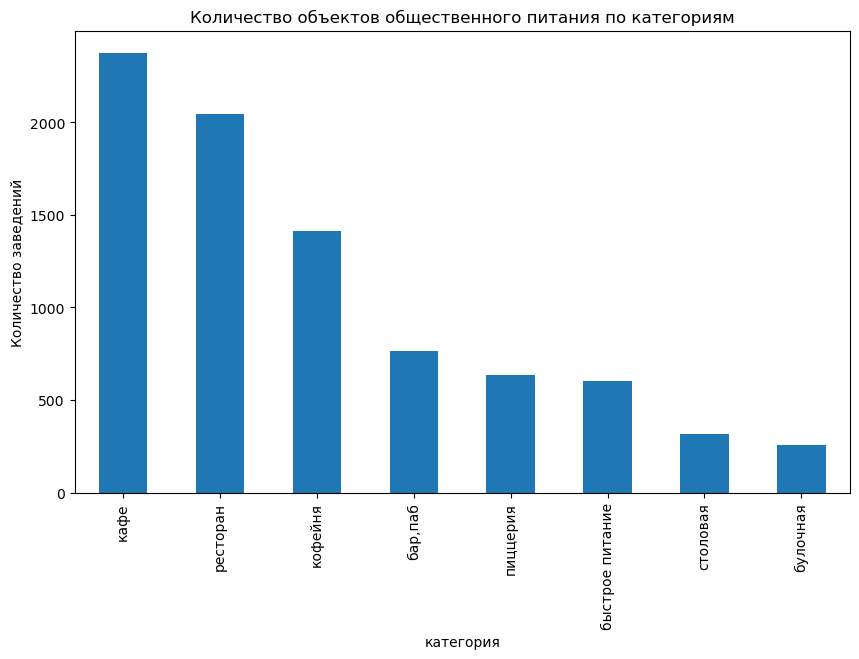

In [28]:
plt.figure(figsize=(10,6))
df_cat.plot(kind='bar', xlabel='категория', ylabel='Количество заведений', title='Количество объектов общественного питания по категориям')
plt.show()

---

### Задача 2

Проверим количество заведений по районам в абсолютных и относительных значений.


In [29]:
df_dis = df.groupby('district')['id'].count().sort_values(ascending=False)
df_dis

district
Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: id, dtype: int64

In [30]:
df_dis_per = df['district'].value_counts(normalize=True)
df_dis_per

district
Центральный административный округ         0.266841
Северный административный округ            0.106879
Южный административный округ               0.106165
Северо-Восточный административный округ    0.105927
Западный административный округ            0.101166
Восточный административный округ           0.094977
Юго-Восточный административный округ       0.084980
Юго-Западный административный округ        0.084385
Северо-Западный административный округ     0.048679
Name: proportion, dtype: float64

Больше всего заведений сосредаточино в Центральном административном округе Москвы.

Посмотрим распределение заведений по районам с помощью гистораммы.


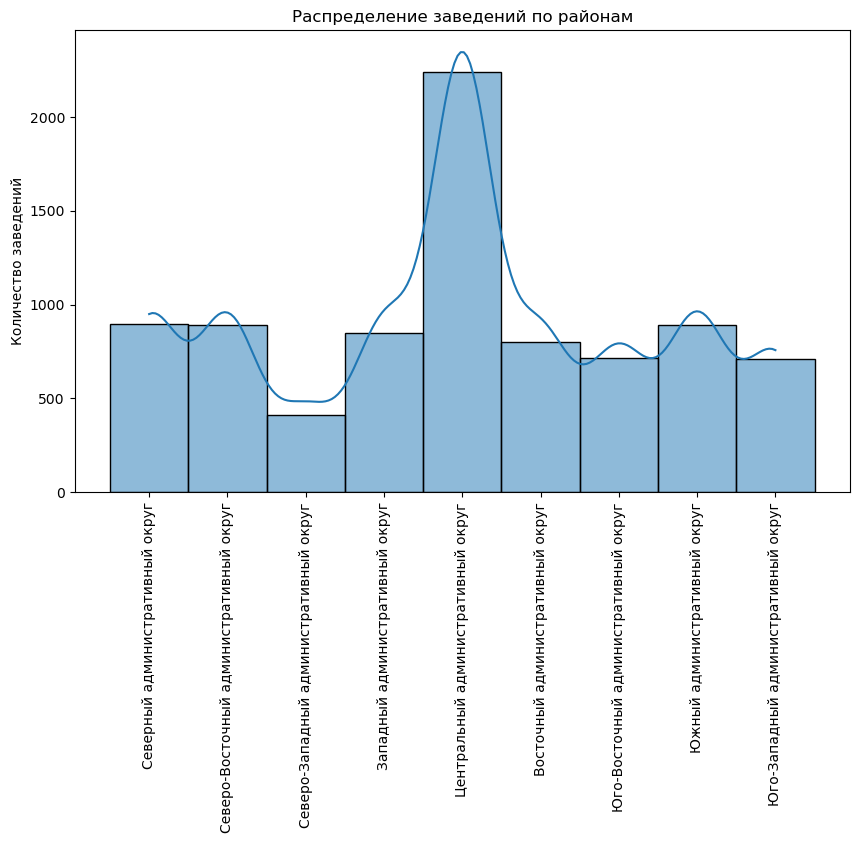

In [31]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='district', kde=True)

ax = plt.gca()
plt.setp(ax.get_xticklabels(), rotation=90)

plt.title('Распределение заведений по районам')
plt.xlabel('')
plt.ylabel('Количество заведений')

plt.show()

Посмотрим количество заведений каждой категории в Центральном административном округе Москвы в абсолютных и относительных значениях.


In [32]:
df_dis_one = df[(df['district'] == 'Центральный административный округ')].groupby('category')['id'].count().sort_values(ascending=False)
df_dis_one

category
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: id, dtype: int64

In [33]:
df_dis_one_per = df[(df['district'] == 'Центральный административный округ')]['category'].value_counts(normalize=True)
df_dis_one_per

category
ресторан           0.298840
кафе               0.206958
кофейня            0.190901
бар,паб            0.162355
пиццерия           0.050401
быстрое питание    0.038805
столовая           0.029438
булочная           0.022302
Name: proportion, dtype: float64

Больше всего в районе ресторанов.


С помощью гистораммы посмотрим распределение заведений каждой категории в Центральном административном округе Москвы.

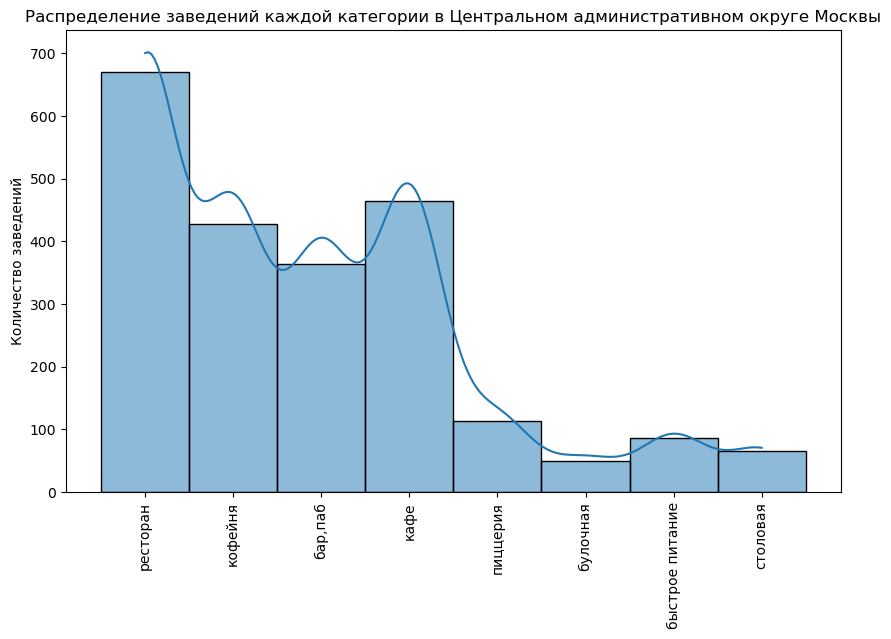

In [34]:
plt.figure(figsize=(10,6))
df_dis_two = df[(df['district'] == 'Центральный административный округ')]
sns.histplot(data=df_dis_two, x='category', kde=True)

ax = plt.gca()
plt.setp(ax.get_xticklabels(), rotation=90)

plt.title('Распределение заведений каждой категории в Центральном административном округе Москвы')
plt.xlabel('')
plt.ylabel('Количество заведений')

plt.show()

---

### Задача 3

Проверим количество сетевых и несетевых заведений в абсолютных и относительных значениях.


In [35]:
df_chain = df.groupby('chain')['id'].count()
df_chain

chain
0    5199
1    3203
Name: id, dtype: int64

In [36]:
df_chain_per = df['chain'].value_counts(normalize=True)
df_chain_per

chain
0    0.618781
1    0.381219
Name: proportion, dtype: float64

Несетевых заведений больше.

Проверим количество сетевых и несетевых заведений относительно категорий с помощью сводной таблицы.


In [37]:
pivot_chain = pd.pivot_table(df, index='category', columns='chain', values='id', aggfunc='count')
pivot_chain

chain,0,1
category,,
"бар,паб",596,168
булочная,99,157
быстрое питание,371,232
кафе,1597,779
кофейня,693,720
пиццерия,303,330
ресторан,1313,729
столовая,227,88


В большинстве категорий преобладают несетевые заведения кроме `булочных`, `кофеин` и `пиццерий`.

Отобразим разницу в количестве сетевых и несетевых заведений с помощью круговой диаграммы.


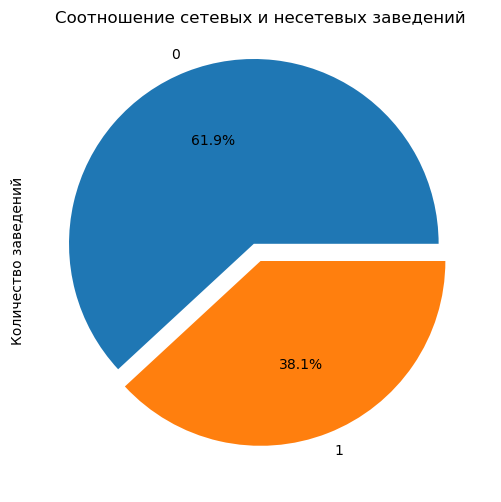

In [38]:
plt.figure(figsize=(10,6))
df_chain.plot(kind='pie', ylabel='Количество заведений', title='Соотношение сетевых и несетевых заведений', autopct='%1.1f%%', explode=(0.1, 0))
plt.show()

Отобразим соотношение сетевых и несетевых заведений в разрезе категорий

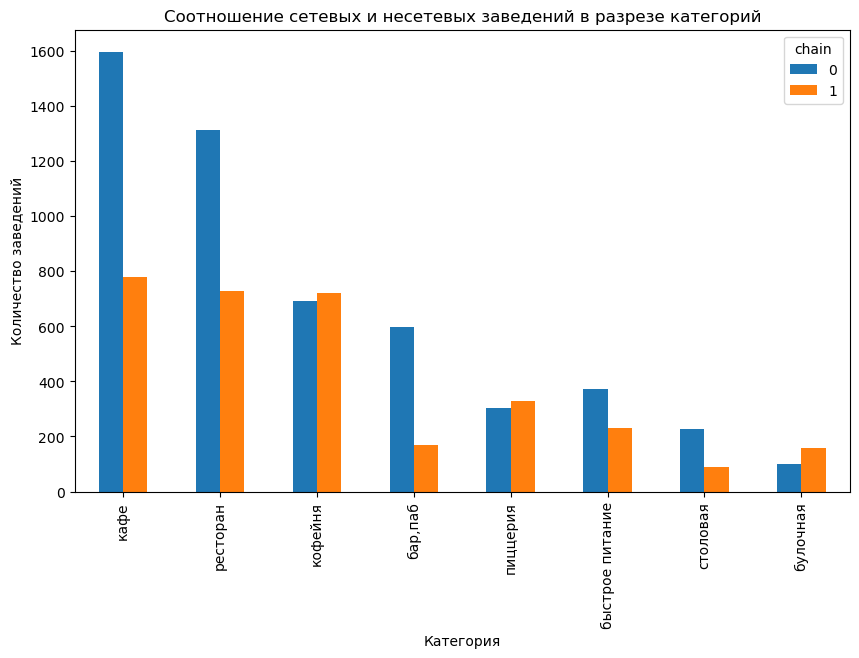

In [39]:
grouped = df.groupby('category')['chain'].value_counts().unstack(fill_value=0)
grouped_sorted = grouped.sum(axis=1).sort_values(ascending=False)
grouped.loc[grouped_sorted.index].plot(kind='bar', xlabel='Категория', ylabel='Количество заведений', title='Соотношение сетевых и несетевых заведений в разрезе категорий', figsize=(10,6))
plt.show()

Больше всего сетевых завдений среди `кафе`, `кофеин` и `ресторанов`, но если оценивать относительно соотношения сетевых и несетевых заведений по категориям - среди `булочных` чаще всего преобладают сетевые заведения.

---

### Задача 4

Для изучения данных о посадочных местах построим диаграмму размаха.

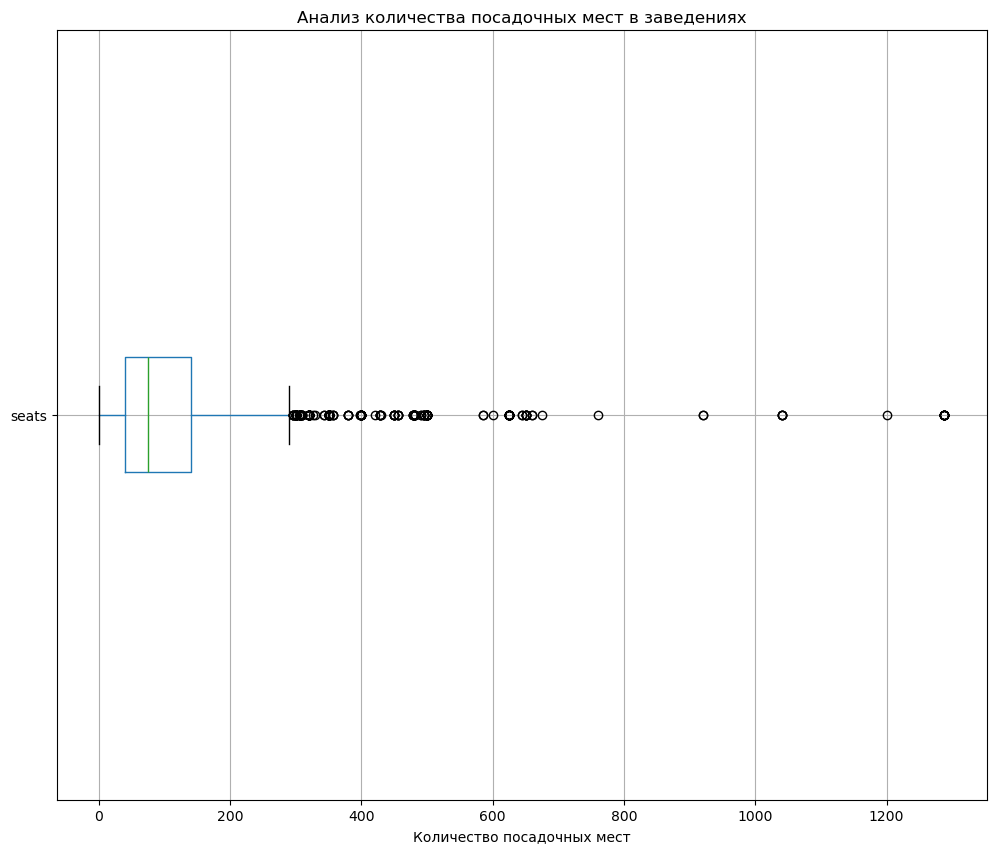

In [40]:
df.boxplot(column='seats', vert=False, figsize=(12,10))
plt.xlabel('Количество посадочных мест')
plt.title('Анализ количества посадочных мест в заведениях')
plt.show()

В правой части много выбросов. Такое явление может быть связано с различием в среднем количестве мест в зависимости от категории заведения.

Чтобы точнее понять, какое количество мест встречается чаще, используем медиану.

In [41]:
seats_median = df['seats'].median()
seats_median

75.0

Чаще всего в заведениях 75 мест.

Изучим медиану количества мест заведений относительно категорий.


In [42]:
seats_mean = df.groupby('category')['seats'].median().sort_values(ascending=False)
seats_mean

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64

Для изучения происхождения выбросов данных изучим максимальное и минимальное количество мест для каждой категории заведений.


In [43]:
seats_min_max = df.groupby('category')['seats'].agg(['min', 'max'])
seats_min_max

,min,max
category,,
"бар,паб",0.0,1288.0
булочная,0.0,625.0
быстрое питание,0.0,1040.0
кафе,0.0,1288.0
кофейня,0.0,1288.0
пиццерия,0.0,1288.0
ресторан,0.0,1288.0
столовая,0.0,1200.0


Во всех категория количество мест варируется от 0 до 1000, кроме булочных.

---

### Задача 5

Проверим средний рейтинг для различных категорий заведений.

In [44]:
df_rat = df.groupby('category')['rating'].mean()
df_rat

category
бар,паб            4.387696
булочная           4.268359
быстрое питание    4.050249
кафе               4.124284
кофейня            4.277282
пиццерия           4.301264
ресторан           4.290401
столовая           4.211429
Name: rating, dtype: float32

Визуализируем полученные данные с помощью столбчатой диаграммы.

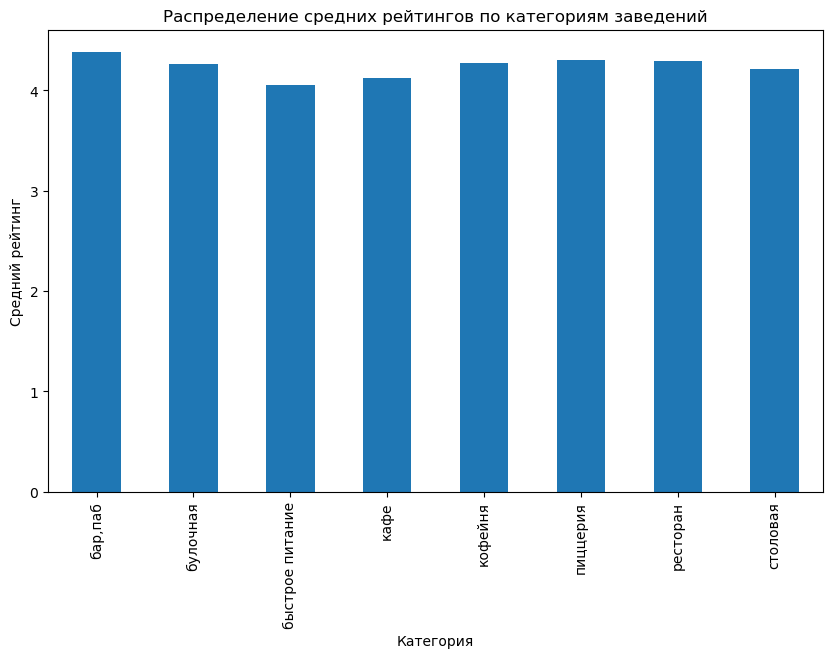

In [45]:
plt.figure(figsize=(10,6))
df_rat.plot(kind='bar', title='Распределение средних рейтингов по категориям заведений', xlabel='Категория', ylabel='Средний рейтинг')
plt.show()

Можно заметить, что средний рейтинг не сильно различается в зависимости от категории.

### Задача 6


Проверим корреляцию рейтинга с остальными данными.

In [46]:
from phik import phik_matrix
correlation_matrix = df[['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']].phik_matrix()
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['rating', 'chain', 'seats']


,rating
price,0.262056
category,0.198739
district,0.189453
is_24_7,0.161010
chain,0.118857
seats,0.000000


Самая сильная корреляция рейтинга с ценой.

Визуализируем корреляцию с помощью тепловой карты.


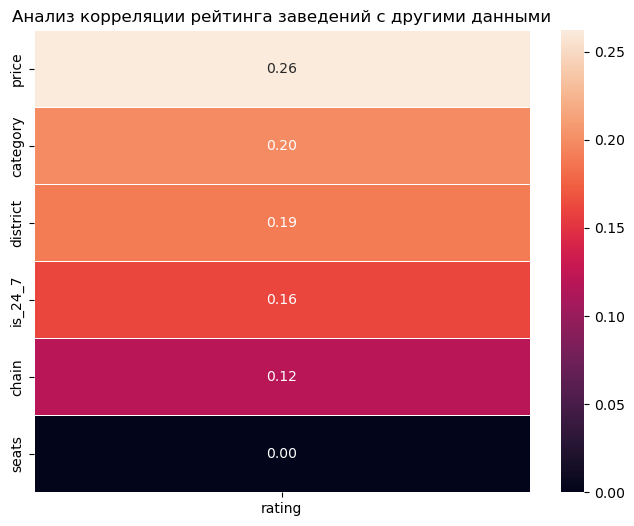

In [47]:
plt.figure(figsize=(8,6))
sns.heatmap(data=correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False), annot=True, fmt='.2f', cmap='rocket', linewidths=0.5)
plt.title('Анализ корреляции рейтинга заведений с другими данными')
plt.show()

Проверим как в зависимости от категории цены меняется средний рейтинг заведений.

In [48]:
df_pr_r = df.groupby('price')['rating'].mean().sort_values(ascending=False)
df_pr_r

price
высокие          4.436611
выше среднего    4.386347
средние          4.297874
низкие           4.173077
Name: rating, dtype: float32

Можно заметить, что при снижении ценовой категории снижается и рейтинг.

---

### Задача 7



Посмотрим топ-15 заведений с их средним средним рейтингом и категорией.

In [49]:
df_top = df[(df['chain'] == 1)].groupby('name').agg({'id':'count', 'rating':'mean', 'category': 'first'}).sort_values(by='id', ascending=False)
df_top.head(15)

,id,rating,category
name,,,
шоколадница,120,4.177500,кофейня
домино'с пицца,76,4.169737,пиццерия
додо пицца,74,4.286487,пиццерия
one price coffee,71,4.064789,кофейня
яндекс лавка,69,3.872464,ресторан
cofix,65,4.075385,кофейня
prime,50,4.116000,ресторан
хинкальная,44,4.322727,быстрое питание
кофепорт,42,4.147619,кофейня


Самая популярная сеть - `Шоколадница`.

Посмотрим рейтинг на столбчатой диаграмме.

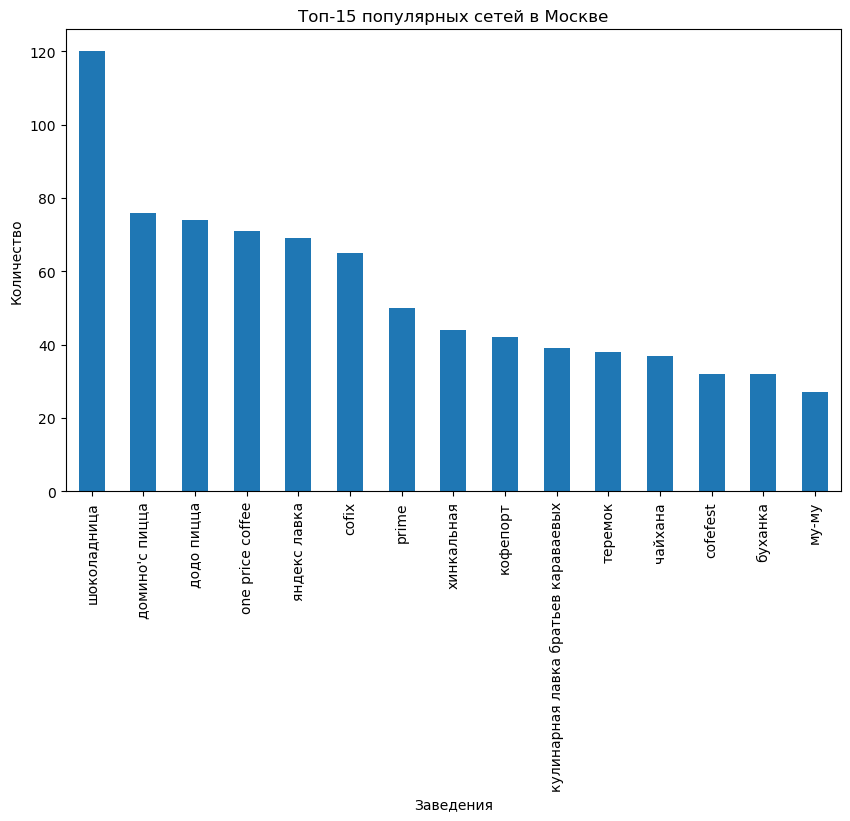

In [50]:
df_top.head(15).plot(kind='bar', y='id', xlabel='Заведения', ylabel='Количество', title='Топ-15 популярных сетей в Москве', legend=False, figsize=(10,6))
plt.show()

Проверим, есть ли взаимосвязь между количеством заведений и рейтингом с помощью диаграммы рассеяния.

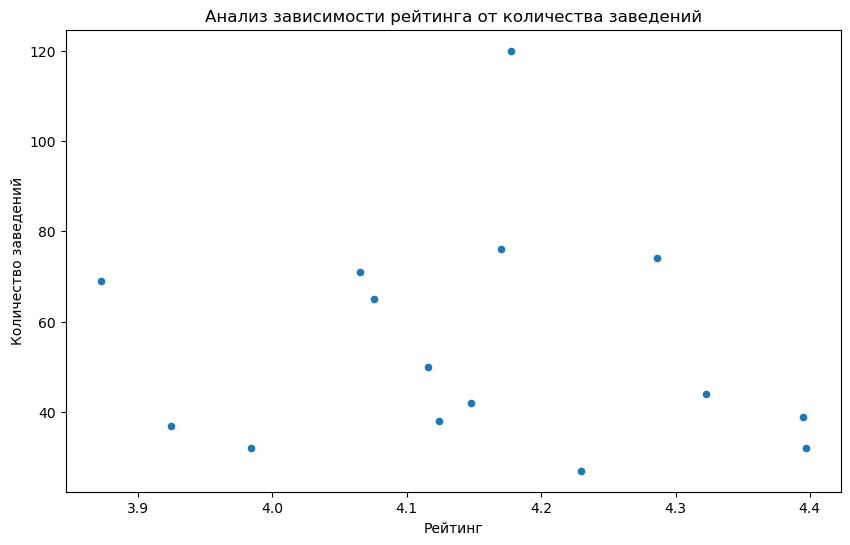

In [51]:
df_top.head(15).plot(kind='scatter', x='rating', y='id', xlabel='Рейтинг', ylabel='Количество заведений', title='Анализ зависимости рейтинга от количества заведений', figsize=(10,6))
plt.show()

Можно удидеть, что зависимости нет.

Посмотрим к каким категориям относятся топ-15 заведений.

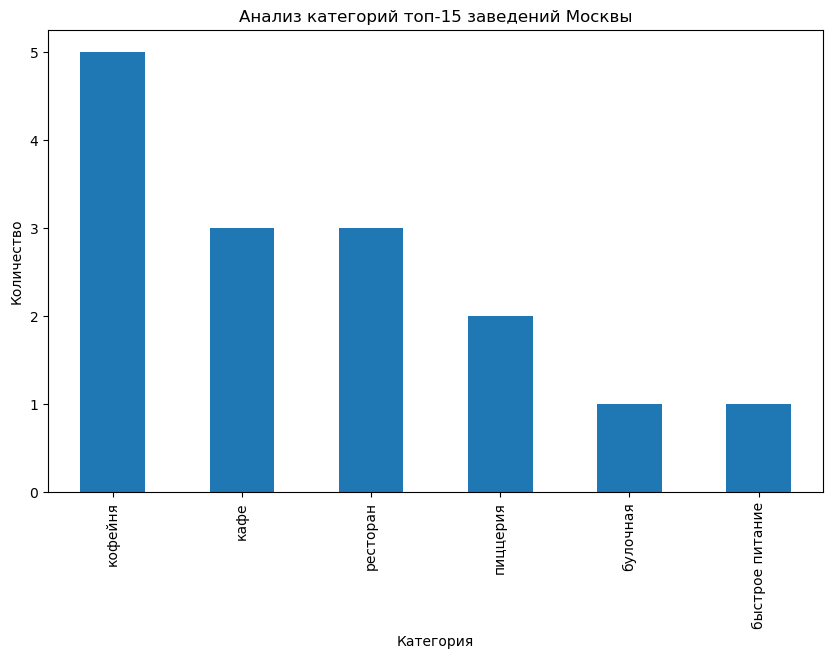

In [52]:
df_top_cat = df_top.head(15).groupby('category')['id'].count().sort_values(ascending=False)

df_top_cat.plot(kind='bar', xlabel='Категория', ylabel='Количество', title='Анализ категорий топ-15 заведений Москвы', figsize=(10,6))
plt.show()

Можно заметить, что больше всего среди топ-15 заведений `кофеин`.

---

### Задача 8



Изучим как средний чек в заведениях меняется в зависимости от района, используя медиану (чтобы опираться на то, какой средний чек втсречается чаше среди заведений района).

In [53]:
df_avg = df.groupby('district')['middle_avg_bill'].median().sort_values(ascending=False)
df_avg

district
Западный административный округ            1000.0
Центральный административный округ         1000.0
Северо-Западный административный округ      700.0
Северный административный округ             650.0
Юго-Западный административный округ         600.0
Восточный административный округ            575.0
Северо-Восточный административный округ     500.0
Южный административный округ                500.0
Юго-Восточный административный округ        450.0
Name: middle_avg_bill, dtype: float64

Можно заметить, что по мере удаленности районов от центра цена уменьшается. Самый высокий средний чек в центральном районе. 

Для большей наглядности создадим столбчатую диаграмму.

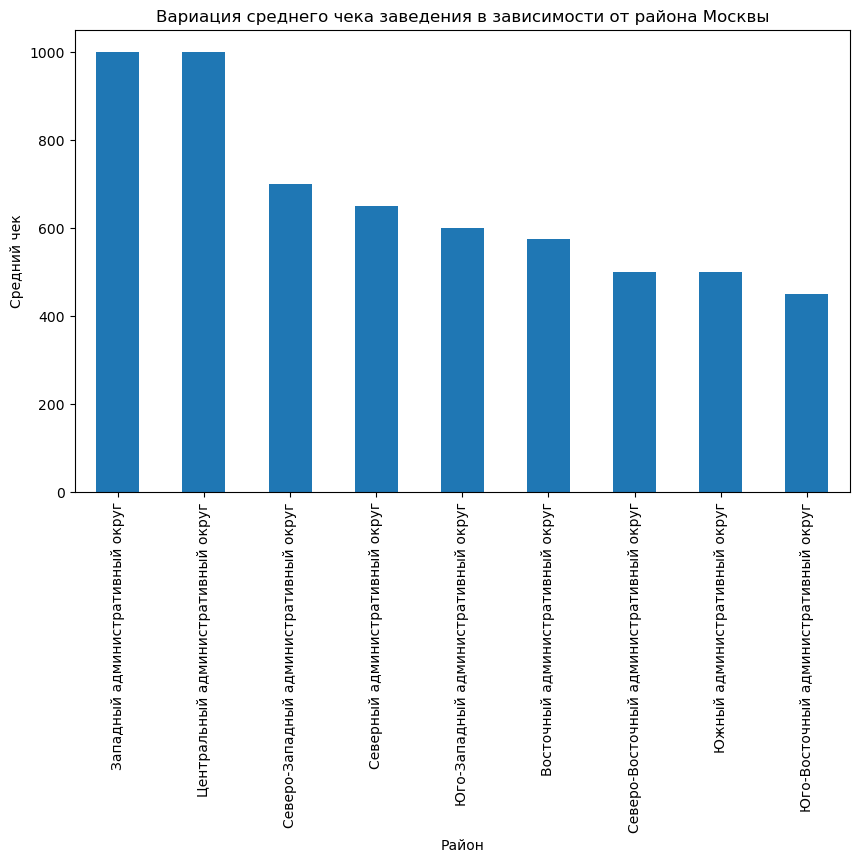

In [54]:
df_avg.plot(kind='bar', xlabel='Район', ylabel='Средний чек', title='Вариация среднего чека заведения в зависимости от района Москвы', figsize=(10,6))
plt.show()

---


---

### Промежуточный вывод

В ходе исследовательского анализа данных были сделаны следующие выводы:

- Всего 8 категорий заведений прелставлено в данных. Больше всего заведений представлено в категории `кафе`, `ресторан` и `кофейня`.
- Больше всего заведений сосредаточино в `Центральном административном округе` Москвы. Больше всего в районе `ресторанов`.
- Несетевых заведений по Москве больше. Чаще всего сетевые завдения встречаются среди `кафе`, `кофеин` и `ресторанов`, но если оценивать относительно соотношения сетевых и несетевых заведений по категориям - среди `булочных` чаще всего преобладают сетевые заведения.
- Медиана посадочных мест - 75, но в данных присутствуют выбросы, которые могут быть связаны с тем, что количество посадочных мест в каждой категории сильно варируется от 0 до 1000 из-за различия в размерах помещений.
- Средний рейтинг заведений не сильно различается в зависимости от категории.
- Самая сильная корреляция рейтинга с ценой. При снижении ценовой категории снижается и рейтинг.
- Самая популярная сеть - `Шоколадница`. 
- Взаимосвязи между количеством заведений и рейтингом топ-15 заведений - нет. Больше всего среди топ-15 заведений `кофеин`.
- По мере удаленности районов от центра цена уменьшается. Самый высокий средний чек в центральном и западном районе.

## 4. Итоговый вывод и рекомендации

В ходе работы были совершены: выгрузка, предобработка и исследовательский анализ данных из датасета с заведениям общественного питания Москвы.

После проведения анализа данных можно сделать следующие выводы:

- Больше всего заведений представлено в категории кафе, ресторан и кофейня
- Больше всего заведений сосредаточино в Центральном административном округе Москвы.
- Несетевых заведений по Москве больше.
- Средний рейтинг заведений не сильно различается в зависимости от категории.
- При снижении ценовой категории снижается и рейтинг.
- Больше всего среди топ-15 заведений кофеин.
- По мере удаленности районов от центра цена уменьшается.

Рекомендации на основе полученных данных:

- Хорошим вариантом для старта может стать бар, их не так много как ресторанов или кафе, потому конкуренция будет меньше.
- Лучше всего для расположения выбирать Северо-Западный или Северный административный округ. Там средний чек меньше, чем в центральном районе, но и конкуренция меньше. При этом цена все равно остается выше средний, а значит и выручка вполне сможет покрыть расходы на запуск (так же учитываем корреляцию рейтинга и цены).

